# Measuring Dependence: Multivariate (2D) Variables

This notebook extends the 1D dependence analysis to **multivariate**
random vectors $X \in \mathbb{R}^2$ and $Y \in \mathbb{R}^2$.

We compare classical matrix-based dependence measures with RBIG-based
Mutual Information on two synthetic datasets with different nonlinear
structures.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

from rbig import AnnealedRBIG, mutual_information_rbig

/home/azureuser/localfiles/rbig/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Dataset 1: Asymmetric nonlinearity

$$
\begin{aligned}
y_0 &= (2 x_0)^2 + \varepsilon \\
y_1 &= 0.2 x_0 + \sqrt{2|x_1|} + 0.1 \varepsilon
\end{aligned}
$$

Cross-dimensional dependencies with different nonlinear forms — $y_0$
depends only on $x_0$ (quadratic), while $y_1$ depends on both $x_0$
(linear) and $x_1$ (square-root).

In [2]:
rng = np.random.RandomState(42)
N = 1000

x1 = rng.randn(N, 2)
noise1 = rng.randn(N, 1)
y1 = np.column_stack([
    (2 * x1[:, 0]) ** 2 + noise1.ravel(),
    0.2 * x1[:, 0] + np.sqrt(2 * np.abs(x1[:, 1])) + 0.1 * noise1.ravel(),
])

### Scatter plots: all pairwise relationships

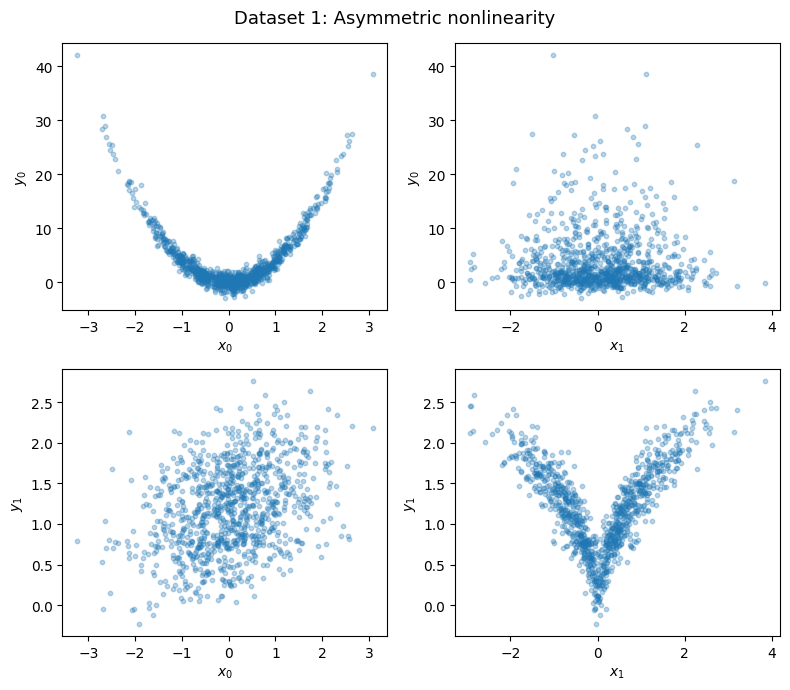

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(8, 7))
labels = [("$x_0$", "$y_0$"), ("$x_1$", "$y_0$"), ("$x_0$", "$y_1$"), ("$x_1$", "$y_1$")]
pairs = [(0, 0), (1, 0), (0, 1), (1, 1)]
for ax, (xi, yi), (xl, yl) in zip(axes.ravel(), pairs, labels):
    ax.scatter(x1[:, xi], y1[:, yi], alpha=0.3, s=10)
    ax.set(xlabel=xl, ylabel=yl)
fig.suptitle("Dataset 1: Asymmetric nonlinearity", fontsize=13)
fig.tight_layout()
plt.show()

### Classical measures

In [4]:
# Hilbert-Schmidt score: ||X^T Y||_F
hs_score = np.linalg.norm(x1.T @ y1, "fro")
hs_norm = hs_score / (np.linalg.norm(x1.T @ x1, "fro") * np.linalg.norm(y1.T @ y1, "fro"))

# Spearman on stacked [X, Y]
stacked = np.hstack([x1, y1])
spearman_matrix = stats.spearmanr(stacked).statistic
# Extract cross-correlation block (X cols vs Y cols)
spearman_xy = spearman_matrix[:2, 2:]
spearman_fro = np.linalg.norm(spearman_xy, "fro")

print("Dataset 1 — classical measures:")
print(f"  HS score:      {hs_score:.4f}")
print(f"  HS normalized: {hs_norm:.4f}")
print(f"  Spearman cross-block Frobenius: {spearman_fro:.4f}")

Dataset 1 — classical measures:
  HS score:      471.6632
  HS normalized: 0.0000
  Spearman cross-block Frobenius: 0.3328


### Mutual Information via RBIG

In [5]:
model_x1 = AnnealedRBIG(n_layers=50, rotation="pca", random_state=42)
model_y1 = AnnealedRBIG(n_layers=50, rotation="pca", random_state=42)
model_xy1 = AnnealedRBIG(n_layers=50, rotation="pca", random_state=42)

model_x1.fit(x1)
model_y1.fit(y1)
model_xy1.fit(np.hstack([x1, y1]))

mi1 = mutual_information_rbig(model_x1, model_y1, model_xy1)
icc1 = np.sqrt(1 - np.exp(-2 * mi1))

print(f"  MI (RBIG): {mi1:.4f} nats")
print(f"  ICC:       {icc1:.4f}")

  MI (RBIG): 54.5359 nats
  ICC:       1.0000


## Dataset 2: Symmetric quadratic (higher noise)

$$
\begin{aligned}
y_0 &= (2 x_0)^2 + 3\varepsilon_0 \\
y_1 &= (2 x_1)^2 + 3\varepsilon_1
\end{aligned}
$$

Independent per-dimension quadratics with higher noise — weaker signal.

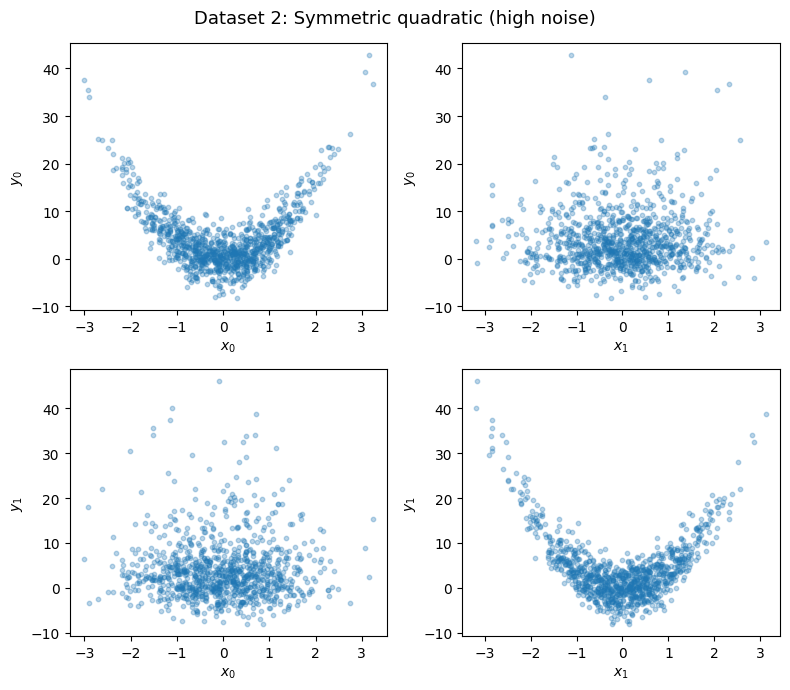

In [6]:
x2 = rng.randn(N, 2)
y2 = np.column_stack([
    (2 * x2[:, 0]) ** 2 + 3 * rng.randn(N),
    (2 * x2[:, 1]) ** 2 + 3 * rng.randn(N),
])

fig, axes = plt.subplots(2, 2, figsize=(8, 7))
for ax, (xi, yi), (xl, yl) in zip(axes.ravel(), pairs, labels):
    ax.scatter(x2[:, xi], y2[:, yi], alpha=0.3, s=10)
    ax.set(xlabel=xl, ylabel=yl)
fig.suptitle("Dataset 2: Symmetric quadratic (high noise)", fontsize=13)
fig.tight_layout()
plt.show()

### Classical measures + MI

In [7]:
hs_score2 = np.linalg.norm(x2.T @ y2, "fro")
hs_norm2 = hs_score2 / (np.linalg.norm(x2.T @ x2, "fro") * np.linalg.norm(y2.T @ y2, "fro"))

spearman2 = stats.spearmanr(np.hstack([x2, y2])).statistic
spearman_xy2 = spearman2[:2, 2:]
spearman_fro2 = np.linalg.norm(spearman_xy2, "fro")

model_x2 = AnnealedRBIG(n_layers=50, rotation="pca", random_state=42)
model_y2 = AnnealedRBIG(n_layers=50, rotation="pca", random_state=42)
model_xy2 = AnnealedRBIG(n_layers=50, rotation="pca", random_state=42)
model_x2.fit(x2)
model_y2.fit(y2)
model_xy2.fit(np.hstack([x2, y2]))

mi2 = mutual_information_rbig(model_x2, model_y2, model_xy2)
icc2 = np.sqrt(1 - np.exp(-2 * mi2))

print("Dataset 2 — classical measures:")
print(f"  HS score:      {hs_score2:.4f}")
print(f"  HS normalized: {hs_norm2:.4f}")
print(f"  Spearman cross-block Frobenius: {spearman_fro2:.4f}")
print(f"  MI (RBIG): {mi2:.4f} nats")
print(f"  ICC:       {icc2:.4f}")

Dataset 2 — classical measures:
  HS score:      1199.2699
  HS normalized: 0.0000
  Spearman cross-block Frobenius: 0.0551
  MI (RBIG): 73.4005 nats
  ICC:       1.0000


## Comparison summary

| Metric | Dataset 1 (asymmetric) | Dataset 2 (symmetric, noisy) |
|--------|:---------------------:|:---------------------------:|
| HS norm | low | low |
| Spearman cross-Frobenius | low | low |
| MI (RBIG) | **high** | **moderate** |
| ICC | **high** | **moderate** |

Again, MI detects nonlinear multivariate dependence that classical
matrix-based measures largely miss. Dataset 2 shows lower MI due to
the higher noise level, correctly reflecting the weaker signal.